<a href="https://colab.research.google.com/github/Ashwani-Pathak/Customer-Segmentation-and-Transaction-Analysis/blob/main/Customer_Segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

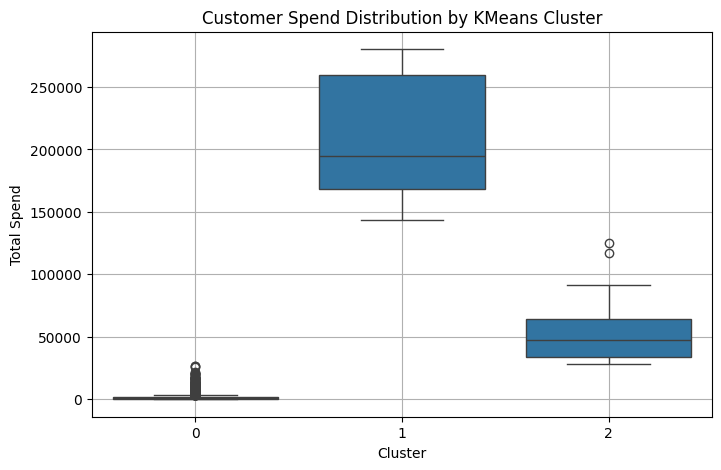

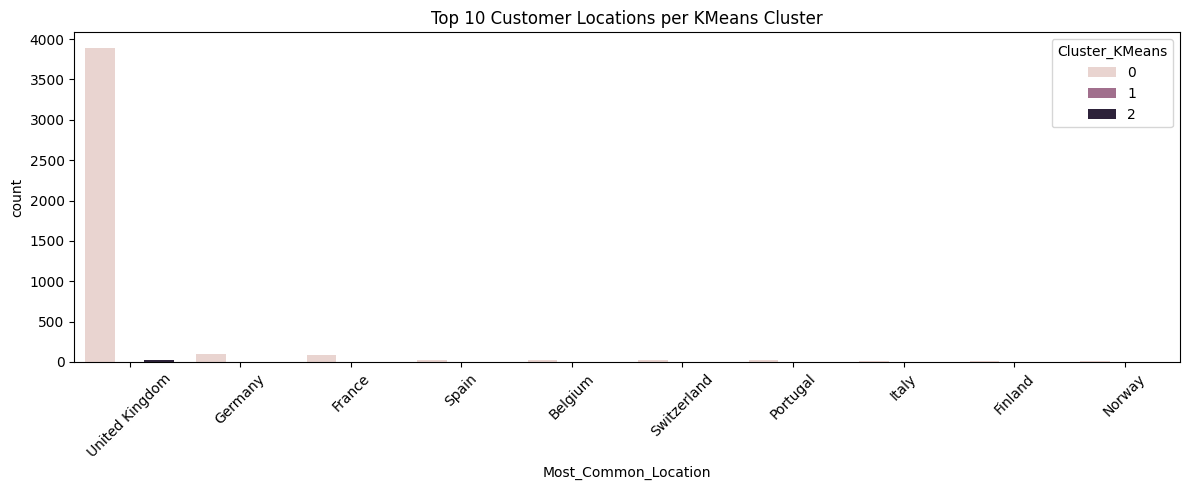


🔍 KMeans Clustering Insights

Cluster 0:
Customers: 4303
Avg Spend: $1455.66
Avg Purchase Interval: 128.94 days
Top Locations: {'United Kingdom': 3890, 'Germany': 94, 'France': 87}
Top Items: {'POST': 117, '85123A': 100, 22423: 83}

Cluster 1:
Customers: 5
Avg Spend: $209342.33
Avg Purchase Interval: 330.80 days
Top Locations: {'United Kingdom': 3, 'Netherlands': 1, 'EIRE': 1}
Top Items: {22629: 1, 'C2': 1, 22980: 1}

Cluster 2:
Customers: 30
Avg Spend: $53366.49
Avg Purchase Interval: 313.33 days
Top Locations: {'United Kingdom': 27, 'Australia': 1, 'EIRE': 1}
Top Items: {22197: 3, '85099B': 3, 79321: 2}


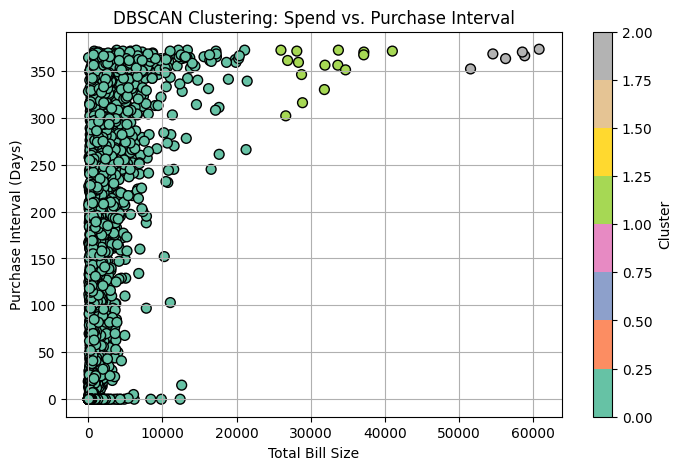


🔍 DBSCAN Clustering Insights

Cluster 0:
Customers: 4300
Avg Spend: $1438.19
Avg Purchase Interval: 128.79 days
Top Locations: {'United Kingdom': 3887, 'Germany': 94, 'France': 87}

Cluster 1:
Customers: 15
Avg Spend: $31642.51
Avg Purchase Interval: 353.33 days
Top Locations: {'United Kingdom': 14, 'Sweden': 1}

Cluster 2:
Customers: 6
Avg Spend: $56736.39
Avg Purchase Interval: 365.33 days
Top Locations: {'United Kingdom': 6}


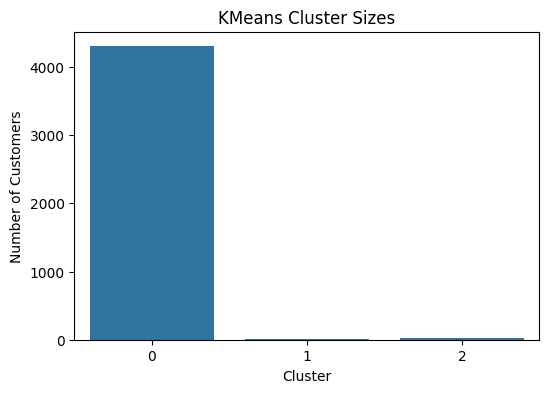

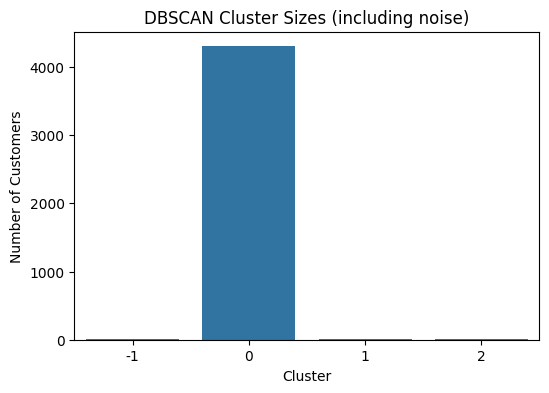

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN

# Load dataset
data_url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00352/Online%20Retail.xlsx'
df = pd.read_excel(data_url)

# Preprocessing
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df = df[df['Quantity'] > 0]  # Remove returns
df = df[df['UnitPrice'] > 0]
df['Total_Bill'] = df['Quantity'] * df['UnitPrice']

# Aggregate customer-level data
customer_df = df.groupby('CustomerID').agg(
    Total_Bill_Size=('Total_Bill', 'sum'),
    First_Purchase=('InvoiceDate', 'min'),
    Last_Purchase=('InvoiceDate', 'max'),
    Most_Common_Location=('Country', lambda x: x.mode()[0]),
    Top_Item=('StockCode', lambda x: x.value_counts().idxmax())
).reset_index()

# Purchase interval
customer_df['Purchase_Interval_Days'] = (customer_df['Last_Purchase'] - customer_df['First_Purchase']).dt.days

# Scale features
scaler = StandardScaler()
customer_df['Total_Bill_Scaled'] = scaler.fit_transform(customer_df[['Total_Bill_Size']])
features_scaled = scaler.fit_transform(customer_df[['Total_Bill_Size', 'Purchase_Interval_Days']])

# ----------------- KMEANS ------------------
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
customer_df['Cluster_KMeans'] = kmeans.fit_predict(customer_df[['Total_Bill_Scaled']])

# 📊 KMeans Bar Plot
plt.figure(figsize=(8, 5))
sns.boxplot(x='Cluster_KMeans', y='Total_Bill_Size', data=customer_df)
plt.title('Customer Spend Distribution by KMeans Cluster')
plt.xlabel('Cluster')
plt.ylabel('Total Spend')
plt.grid(True)
plt.show()

# 🌍 Country Distribution per KMeans Cluster
plt.figure(figsize=(12, 5))
sns.countplot(x='Most_Common_Location', hue='Cluster_KMeans', data=customer_df, order=customer_df['Most_Common_Location'].value_counts().index[:10])
plt.title('Top 10 Customer Locations per KMeans Cluster')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 📌 Cluster insights (KMeans)
def summarize_kmeans(df):
    print("\n🔍 KMeans Clustering Insights")
    for i in sorted(df['Cluster_KMeans'].unique()):
        group = df[df['Cluster_KMeans'] == i]
        print(f"\nCluster {i}:")
        print(f"Customers: {len(group)}")
        print(f"Avg Spend: ${group['Total_Bill_Size'].mean():.2f}")
        print(f"Avg Purchase Interval: {group['Purchase_Interval_Days'].mean():.2f} days")
        print("Top Locations:", group['Most_Common_Location'].value_counts().head(3).to_dict())
        print("Top Items:", group['Top_Item'].value_counts().head(3).to_dict())

summarize_kmeans(customer_df)

# ----------------- DBSCAN ------------------
dbscan = DBSCAN(eps=0.5, min_samples=5)
customer_df['Cluster_DBSCAN'] = dbscan.fit_predict(features_scaled)

# 🧼 Remove noise points (-1) for clarity
non_noise = customer_df[customer_df['Cluster_DBSCAN'] != -1]

# 📈 DBSCAN Scatter
plt.figure(figsize=(8, 5))
plt.scatter(
    non_noise['Total_Bill_Size'],
    non_noise['Purchase_Interval_Days'],
    c=non_noise['Cluster_DBSCAN'],
    cmap='Set2',
    s=50,
    edgecolor='k'
)
plt.title('DBSCAN Clustering: Spend vs. Purchase Interval')
plt.xlabel('Total Bill Size')
plt.ylabel('Purchase Interval (Days)')
plt.grid(True)
plt.colorbar(label='Cluster')
plt.show()

# 📌 Cluster insights (DBSCAN)
def summarize_dbscan(df):
    print("\n🔍 DBSCAN Clustering Insights")
    for c in sorted(df['Cluster_DBSCAN'].unique()):
        if c == -1:
            continue
        group = df[df['Cluster_DBSCAN'] == c]
        print(f"\nCluster {c}:")
        print(f"Customers: {len(group)}")
        print(f"Avg Spend: ${group['Total_Bill_Size'].mean():.2f}")
        print(f"Avg Purchase Interval: {group['Purchase_Interval_Days'].mean():.2f} days")
        print("Top Locations:", group['Most_Common_Location'].value_counts().head(3).to_dict())

summarize_dbscan(customer_df)

# 📊 Cluster Size Comparison
plt.figure(figsize=(6, 4))
sns.countplot(x='Cluster_KMeans', data=customer_df)
plt.title('KMeans Cluster Sizes')
plt.xlabel('Cluster')
plt.ylabel('Number of Customers')
plt.show()

plt.figure(figsize=(6, 4))
sns.countplot(x='Cluster_DBSCAN', data=customer_df)
plt.title('DBSCAN Cluster Sizes (including noise)')
plt.xlabel('Cluster')
plt.ylabel('Number of Customers')
plt.show()
